In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 让图表正常显示中文
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

df = pd.read_csv('ecommerce_sales.csv')
df.head()


,订单号,订单日期,产品类别,产品名称,销售区域,城市,销售渠道,客户类型,数量,单价,折扣率,销售额
0,ORD20262697,2024-01-01,家居用品,北欧落地灯,华中,长沙,线上商城,个人用户,5,781.83,0.0,3909.15
1,ORD20265039,2024-01-01,美妆个护,防晒喷雾,华中,长沙,线下门店,会员用户,9,572.59,0.3,3607.32
2,ORD20244440,2024-01-01,电子产品,高清显示器,西南,成都,APP,个人用户,7,8902.48,0.3,43622.15
3,ORD20240484,2024-01-01,电子产品,无线蓝牙耳机,华中,长沙,APP,个人用户,7,8290.55,0.3,40623.69
4,ORD20257620,2024-01-01,食品饮料,有机牛奶,西南,重庆,小程序,企业采购,13,274.23,0.1,3208.49


In [10]:
df.info()
print(df.describe())
print("总订单量:", len(df))
print("总销售额: %.0f 元" % df['销售额'].sum())

<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 12 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   订单号     30000 non-null  str    
 1   订单日期    30000 non-null  str    
 2   产品类别    30000 non-null  str    
 3   产品名称    30000 non-null  str    
 4   销售区域    30000 non-null  str    
 5   城市      30000 non-null  str    
 6   销售渠道    30000 non-null  str    
 7   客户类型    30000 non-null  str    
 8   数量      30000 non-null  int64  
 9   单价      30000 non-null  float64
 10  折扣率     30000 non-null  float64
 11  销售额     30000 non-null  float64
dtypes: float64(3), int64(1), str(8)
memory usage: 2.7 MB
                 数量            单价           折扣率           销售额
count  30000.000000  30000.000000  30000.000000  30000.000000
mean       4.682100   1373.338226      0.100015   3896.925024
std        3.699671   2089.451024      0.102483   5694.031843
min        1.000000      9.230000      0.000000      9.580000
25%        2.000

In [11]:
print("缺失值:", df.isnull().sum().sum())
print("重复行:", df.duplicated().sum())
df = df.drop_duplicates()
df['订单日期'] = pd.to_datetime(df['订单日期'])
df['月份'] = df['订单日期'].dt.month


缺失值: 0
重复行: 0


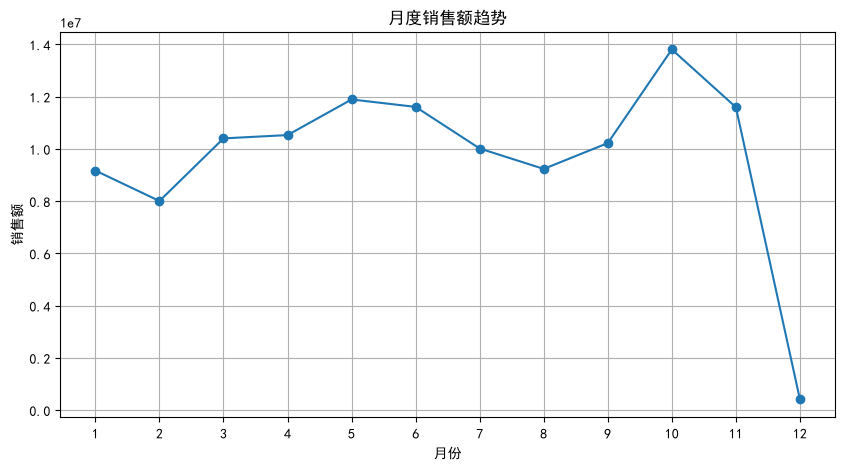

In [12]:
monthly = df.groupby('月份')['销售额'].sum()
plt.figure(figsize=(10,5))
plt.plot(monthly.index, monthly.values, marker='o')
plt.title('月度销售额趋势')
plt.xlabel('月份')
plt.ylabel('销售额')
plt.xticks(range(1,13))
plt.grid(True)
plt.show()


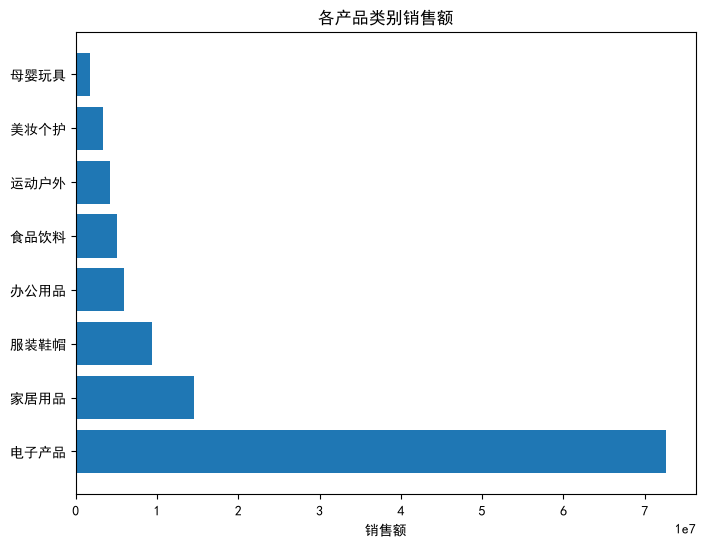

产品类别
电子产品    72640592.36
家居用品    14564356.16
服装鞋帽     9372843.07
办公用品     5966564.29
食品饮料     5101540.55
运动户外     4155794.17
美妆个护     3410714.83
母婴玩具     1695345.28
Name: 销售额, dtype: float64


In [13]:
cat_sales = df.groupby('产品类别')['销售额'].sum().sort_values(ascending=False)
plt.figure(figsize=(8,6))
plt.barh(cat_sales.index, cat_sales.values)
plt.title('各产品类别销售额')
plt.xlabel('销售额')
plt.show()
print(cat_sales)


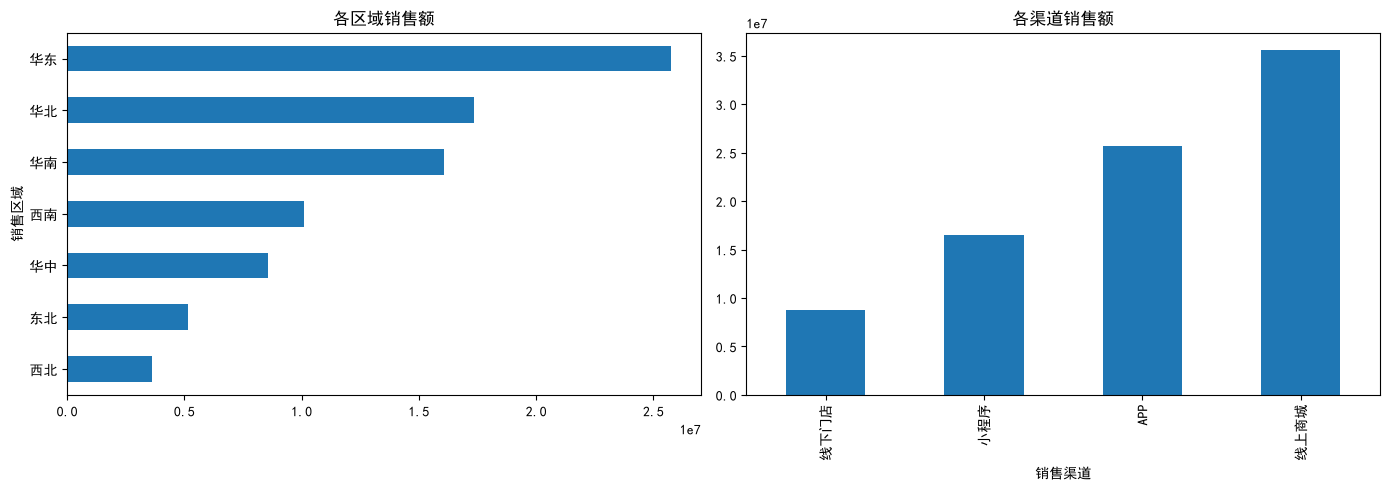

In [7]:
fig, axes = plt.subplots(1,2, figsize=(14,5))
df.groupby('销售区域')['销售额'].sum().sort_values().plot.barh(ax=axes[0], title='各区域销售额')
df.groupby('销售渠道')['销售额'].sum().sort_values().plot.bar(ax=axes[1], title='各渠道销售额')
plt.tight_layout()
plt.show()


In [14]:
df['是否有折扣'] = df['折扣率'] > 0
avg_qty = df.groupby('是否有折扣')['数量'].mean()
print("有折扣平均件数:", round(avg_qty[True],2))
print("无折扣平均件数:", round(avg_qty[False],2))


有折扣平均件数: 5.47
无折扣平均件数: 3.36
